# Analiza datelor de intrare

Acest notebook realizeaza analiza initiala a seturilor de date colectate de dispozitive de tip smartwatch/Fitbit.  
Scopul acestei etape este intelegerea structurii datelor, verificarea calitatii acestora si identificarea variabilelor relevante pentru monitorizarea starii de sanatate.

Datele sunt organizate in folderul `data/` si contin informatii despre:
- activitate zilnica
- ritm cardiac
- calorii
- pasi
- somn
- greutate si BMI


In [116]:
import pandas as pd
import matplotlib.pyplot as plt
import os

## 1. Incarcarea seturilor de date

In aceasta etapa sunt incarcate fisierele CSV disponibile in folderul `data/`.
Fiecare fisier contine un tip diferit de informatie colectata de smartwatch.

In [117]:
data_path = "data"

activity = pd.read_csv(os.path.join(data_path, "dailyActivity_merged.csv"))
heart_rate = pd.read_csv(os.path.join(data_path, "heartrate_seconds_merged.csv"))
hourly_calories = pd.read_csv(os.path.join(data_path, "hourlyCalories_merged.csv"))
hourly_steps = pd.read_csv(os.path.join(data_path, "hourlySteps_merged.csv"))
sleep = pd.read_csv(os.path.join(data_path, "sleepDay_merged.csv"))
weight = pd.read_csv(os.path.join(data_path, "weightLogInfo_merged.csv"))

datasets = {
    "Daily activity": activity,
    "Heart rate": heart_rate,
    "Hourly calories": hourly_calories,
    "Hourly steps": hourly_steps,
    "Sleep": sleep,
    "Weight": weight
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]} randuri, {df.shape[1]} coloane")

Daily activity: 940 randuri, 15 coloane
Heart rate: 2483658 randuri, 3 coloane
Hourly calories: 22099 randuri, 3 coloane
Hourly steps: 22099 randuri, 3 coloane
Sleep: 413 randuri, 5 coloane
Weight: 67 randuri, 8 coloane


## 2. Vizualizarea primelor inregistrari

Pentru a intelege continutul fiecarui set de date, sunt afisate primele randuri din fiecare tabel.

Setul `dailyActivity_merged.csv` contine informatii zilnice colectate de la utilizatorii dispozitivelor smartwatch/Fitbit.  
Datele includ:
- identificatorul utilizatorului (`Id`)
- data inregistrarii (`ActivityDate`)
- numarul total de pasi efectuati (`TotalSteps`)
- distanta totala parcursa (`TotalDistance`)
- distanta asociata activitatilor foarte active, moderat active si usor active
- numarul de minute petrecute in activitati intense (`VeryActiveMinutes`)
- numarul de minute petrecute in activitati moderate (`FairlyActiveMinutes`)
- numarul de minute petrecute in activitati usoare (`LightlyActiveMinutes`)
- timpul petrecut sedentar (`SedentaryMinutes`)
- numarul total de calorii arse (`Calories`)

Acest set de date este important pentru analiza nivelului de activitate fizica, identificarea comportamentului sedentar si evaluarea stilului de viata al utilizatorilor.

In [118]:
activity.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


Setul `heartrate_seconds_merged.csv` contine valori ale ritmului cardiac colectate la intervale foarte scurte de timp de catre dispozitivele smartwatch/Fitbit.

Datele includ:
- identificatorul utilizatorului (`Id`)
- momentul exact al inregistrarii (`Time`)
- valoarea ritmului cardiac masurata in batai pe minut (`Value`)

Acest set de date permite monitorizarea variatiilor pulsului in timp si poate fi utilizat pentru:
- analiza ritmului cardiac
- identificarea valorilor anormale ale pulsului
- detectarea perioadelor de stres sau efort intens
- analiza relatiei dintre activitate fizica si ritmul cardiac

Datele sunt relevante pentru dezvoltarea unor modele AI capabile sa genereze insight-uri personalizate privind starea de sanatate a utilizatorilor.

In [119]:
heart_rate.head()

,Id,Time,Value
0,2022484408,4/12/2016 7:21:00 AM,97
1,2022484408,4/12/2016 7:21:05 AM,102
2,2022484408,4/12/2016 7:21:10 AM,105
3,2022484408,4/12/2016 7:21:20 AM,103
4,2022484408,4/12/2016 7:21:25 AM,101


Setul `hourlyCalories_merged.csv` contine informatii despre numarul de calorii arse de utilizatori inregistrate la nivel de ora de catre dispozitivele smartwatch/Fitbit.

Datele includ:
- identificatorul utilizatorului (`Id`)
- momentul inregistrarii (`ActivityHour`)
- numarul de calorii arse in intervalul respectiv (`Calories`)

Acest set de date permite analiza consumului energetic al utilizatorilor pe parcursul zilei si poate fi utilizat pentru:
- identificarea perioadelor cu activitate intensa
- analiza distributiei consumului caloric pe intervale orare
- corelarea activitatii fizice cu numarul de calorii arse
- analiza obiceiurilor zilnice ale utilizatorilor

Informatiile sunt utile pentru analiza BI si pentru generarea unor recomandari personalizate privind activitatea fizica si stilul de viata.

In [120]:
hourly_calories.head()

,Id,ActivityHour,Calories
0,1503960366,4/12/2016 12:00:00 AM,81
1,1503960366,4/12/2016 1:00:00 AM,61
2,1503960366,4/12/2016 2:00:00 AM,59
3,1503960366,4/12/2016 3:00:00 AM,47
4,1503960366,4/12/2016 4:00:00 AM,48


Setul `hourlySteps_merged.csv` contine informatii despre numarul de pasi efectuati de utilizatori la nivel de ora, colectate de dispozitivele smartwatch/Fitbit.

Datele includ:
- identificatorul utilizatorului (`Id`)
- momentul inregistrarii (`ActivityHour`)
- numarul total de pasi efectuati in intervalul respectiv (`StepTotal`)

Acest set de date permite analiza activitatii fizice pe parcursul zilei si poate fi utilizat pentru:
- identificarea intervalelor orare cu activitate intensa
- analiza obiceiurilor zilnice ale utilizatorilor
- detectarea perioadelor sedentare
- corelarea activitatii fizice cu alte variabile precum ritmul cardiac sau caloriile arse

Datele sunt relevante pentru monitorizarea nivelului de activitate fizica si pentru dezvoltarea unor modele AI capabile sa genereze recomandari personalizate privind sanatatea utilizatorilor.

In [121]:
hourly_steps.head()

,Id,ActivityHour,StepTotal
0,1503960366,4/12/2016 12:00:00 AM,373
1,1503960366,4/12/2016 1:00:00 AM,160
2,1503960366,4/12/2016 2:00:00 AM,151
3,1503960366,4/12/2016 3:00:00 AM,0
4,1503960366,4/12/2016 4:00:00 AM,0


Setul `sleepDay_merged.csv` contine informatii despre somnul utilizatorilor colectate de dispozitivele smartwatch/Fitbit.

Datele includ:
- identificatorul utilizatorului (`Id`)
- data inregistrarii (`SleepDay`)
- numarul total de inregistrari ale somnului (`TotalSleepRecords`)
- numarul total de minute dormite (`TotalMinutesAsleep`)
- timpul total petrecut in pat (`TotalTimeInBed`)

Acest set de date permite analiza calitatii si duratei somnului si poate fi utilizat pentru:
- evaluarea obiceiurilor de somn ale utilizatorilor
- identificarea perioadelor cu somn insuficient
- compararea timpului petrecut in pat cu timpul efectiv dormit
- analiza relatiei dintre somn, activitate fizica si ritmul cardiac

Informatiile sunt importante pentru monitorizarea starii de sanatate si pentru dezvoltarea unor modele AI capabile sa ofere recomandari personalizate privind stilul de viata si odihna utilizatorilor.

In [122]:
sleep.head()

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442
3,1503960366,4/16/2016 12:00:00 AM,2,340,367
4,1503960366,4/17/2016 12:00:00 AM,1,700,712


Setul `weightLogInfo_merged.csv` contine informatii despre greutatea si indicele de masa corporala ale utilizatorilor, colectate prin intermediul dispozitivelor smartwatch/Fitbit.

Datele includ:
- identificatorul utilizatorului (`Id`)
- data si ora inregistrarii (`Date`)
- greutatea in kilograme (`WeightKg`)
- greutatea in pounds (`WeightPounds`)
- procentul de grasime corporala (`Fat`)
- indicele de masa corporala (`BMI`)
- tipul raportarii (`IsManualReport`)
- identificatorul inregistrarii (`LogId`)

Acest set de date permite analiza parametrilor asociati greutatii corporale si poate fi utilizat pentru:
- evaluarea indicelui de masa corporala
- monitorizarea variatiilor de greutate
- analiza relatiei dintre greutate, activitate fizica si somn
- identificarea unor posibile riscuri asociate sedentarismului sau excesului ponderal

Datele sunt relevante pentru dezvoltarea unor modele AI capabile sa genereze recomandari personalizate privind sanatatea si stilul de viata al utilizatorilor.

In [123]:
weight.head()

,Id,Date,WeightKg,WeightPounds,Fat,BMI,IsManualReport,LogId
0,1503960366,5/2/2016 11:59:59 PM,52.599998,115.963147,22.0,22.650000,True,1462233599000
1,1503960366,5/3/2016 11:59:59 PM,52.599998,115.963147,NaN,22.650000,True,1462319999000
2,1927972279,4/13/2016 1:08:52 AM,133.500000,294.317120,NaN,47.540001,False,1460509732000
3,2873212765,4/21/2016 11:59:59 PM,56.700001,125.002104,NaN,21.450001,True,1461283199000
4,2873212765,5/12/2016 11:59:59 PM,57.299999,126.324875,NaN,21.690001,True,1463097599000


## 3. Informatii generale despre date

In aceasta etapa sunt analizate tipurile de date, numarul de valori nenule si coloanele disponibile.

In [124]:
for name, df in datasets.items():
    print("\n=============================")
    print(name)
    print("=============================")
    print(df.info())


Daily activity
<class 'pandas.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        940 non-null    int64  
 1   ActivityDate              940 non-null    str    
 2   TotalSteps                940 non-null    int64  
 3   TotalDistance             940 non-null    float64
 4   TrackerDistance           940 non-null    float64
 5   LoggedActivitiesDistance  940 non-null    float64
 6   VeryActiveDistance        940 non-null    float64
 7   ModeratelyActiveDistance  940 non-null    float64
 8   LightActiveDistance       940 non-null    float64
 9   SedentaryActiveDistance   940 non-null    float64
 10  VeryActiveMinutes         940 non-null    int64  
 11  FairlyActiveMinutes       940 non-null    int64  
 12  LightlyActiveMinutes      940 non-null    int64  
 13  SedentaryMinutes          940 non-null    int64  
 14  Calor

## 4. Verificarea valorilor lipsa

Valorile lipsa pot afecta analiza si modelele AI/ML.  
De aceea, verificam pentru fiecare set de date daca exista coloane cu valori lipsa.

In [125]:
activity.describe()
for name, df in datasets.items():
    print("\n", name)
    print(df.isnull().sum())


 Daily activity
Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64

 Heart rate
Id       0
Time     0
Value    0
dtype: int64

 Hourly calories
Id              0
ActivityHour    0
Calories        0
dtype: int64

 Hourly steps
Id              0
ActivityHour    0
StepTotal       0
dtype: int64

 Sleep
Id                    0
SleepDay              0
TotalSleepRecords     0
TotalMinutesAsleep    0
TotalTimeInBed        0
dtype: int64

 Weight
Id                 0
Date               0
WeightKg           0
WeightPounds       0
Fat               65
BMI                0
IsManualReport    

## 5. Grafice

In aceasta sectiune adaugam ploturi utile pentru intelegerea tiparelor de activitate, puls si somn.

In [126]:
# Incarcarea datelor pentru grafice
activity_viz = activity.copy()
heart_viz = heart_rate.copy()
hourly_steps_viz = hourly_steps.copy()
sleep_viz = sleep.copy()

activity_viz["Date"] = pd.to_datetime(activity_viz["ActivityDate"], format="%m/%d/%Y", errors="coerce")
heart_viz["DateTime"] = pd.to_datetime(heart_viz["Time"], format="%m/%d/%Y %I:%M:%S %p", errors="coerce")
hourly_steps_viz["DateTime"] = pd.to_datetime(hourly_steps_viz["ActivityHour"], format="%m/%d/%Y %I:%M:%S %p", errors="coerce")
sleep_viz["Date"] = pd.to_datetime(sleep_viz["SleepDay"], format="%m/%d/%Y %I:%M:%S %p", errors="coerce")

hourly_steps_viz["Hour"] = hourly_steps_viz["DateTime"].dt.hour
hourly_steps_viz["Weekday"] = hourly_steps_viz["DateTime"].dt.day_name()


### 5.1 Evolutia zilnica a pasilor si caloriilor

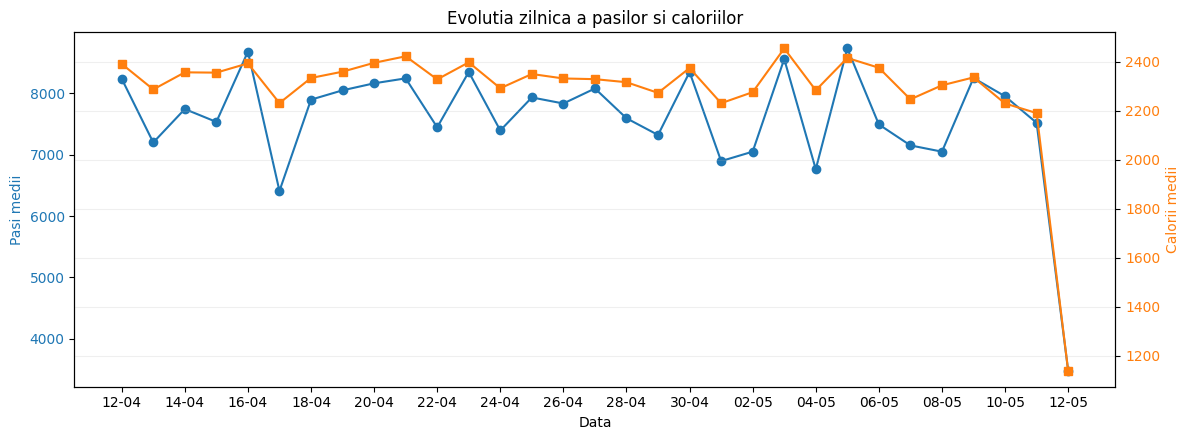

In [127]:
daily_trend = activity_viz.groupby("Date", as_index=False)[["TotalSteps", "Calories"]].mean()

tick_step = max(1, len(daily_trend) // 12)
tick_dates = daily_trend["Date"].iloc[::tick_step]
tick_labels = tick_dates.dt.strftime("%d-%m")

fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax1.plot(daily_trend["Date"], daily_trend["TotalSteps"], color="tab:blue", marker="o", label="Pasi")
ax1.set_xlabel("Data")
ax1.set_ylabel("Pasi medii", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_xticks(tick_dates)
ax1.set_xticklabels(tick_labels)

ax2 = ax1.twinx()
ax2.plot(daily_trend["Date"], daily_trend["Calories"], color="tab:orange", marker="s", label="Calorii")
ax2.set_ylabel("Calorii medii", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.title("Evolutia zilnica a pasilor si caloriilor")
plt.xticks(rotation=35, ha="right")
fig.tight_layout()
plt.grid(alpha=0.2)
plt.show()


### 5.2 Pasi medii pe fiecare ora

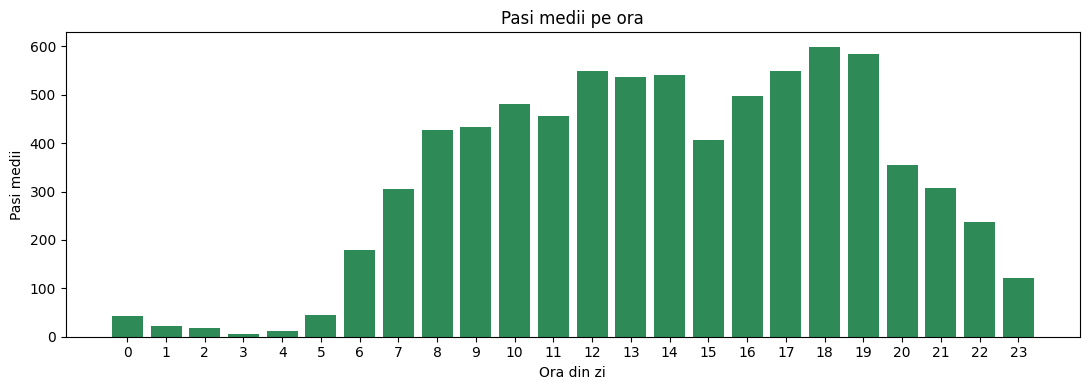

In [128]:
steps_by_hour = hourly_steps_viz.groupby("Hour", as_index=False)["StepTotal"].mean()

plt.figure(figsize=(11, 4))
plt.bar(steps_by_hour["Hour"], steps_by_hour["StepTotal"], color="seagreen")
plt.title("Pasi medii pe ora")
plt.xlabel("Ora din zi")
plt.ylabel("Pasi medii")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

### 5.3 Puls mediu pe fiecare ora

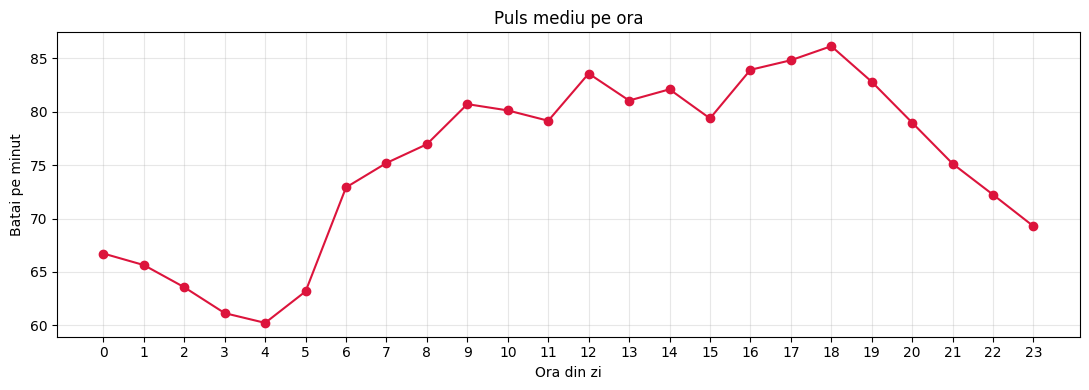

In [129]:
heart_viz["Hour"] = heart_viz["DateTime"].dt.hour
hr_by_hour = heart_viz.groupby("Hour", as_index=False)["Value"].mean()

plt.figure(figsize=(11, 4))
plt.plot(hr_by_hour["Hour"], hr_by_hour["Value"], color="crimson", marker="o")
plt.title("Puls mediu pe ora")
plt.xlabel("Ora din zi")
plt.ylabel("Batai pe minut")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.4 Minute dormite comparat cu timpul in pat

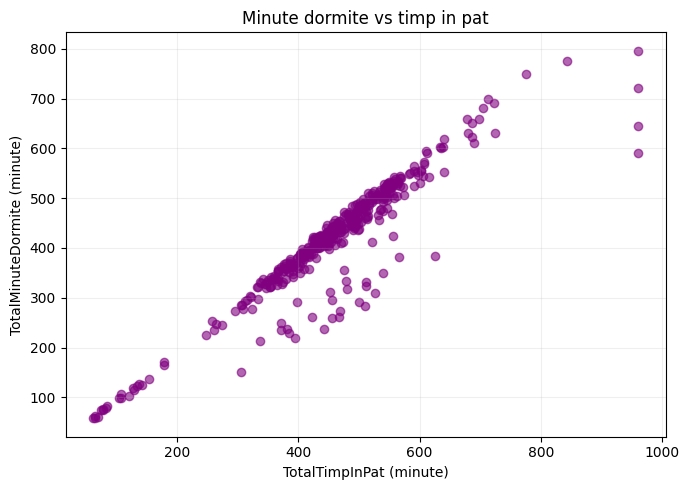

In [130]:
plt.figure(figsize=(7, 5))
plt.scatter(sleep_viz["TotalTimeInBed"], sleep_viz["TotalMinutesAsleep"], alpha=0.6, color="purple")

plt.title("Minute dormite vs timp in pat")
plt.xlabel("TotalTimpInPat (minute)")
plt.ylabel("TotalMinuteDormite (minute)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


### 5.5 Grafic cu pasii pe zile si ore

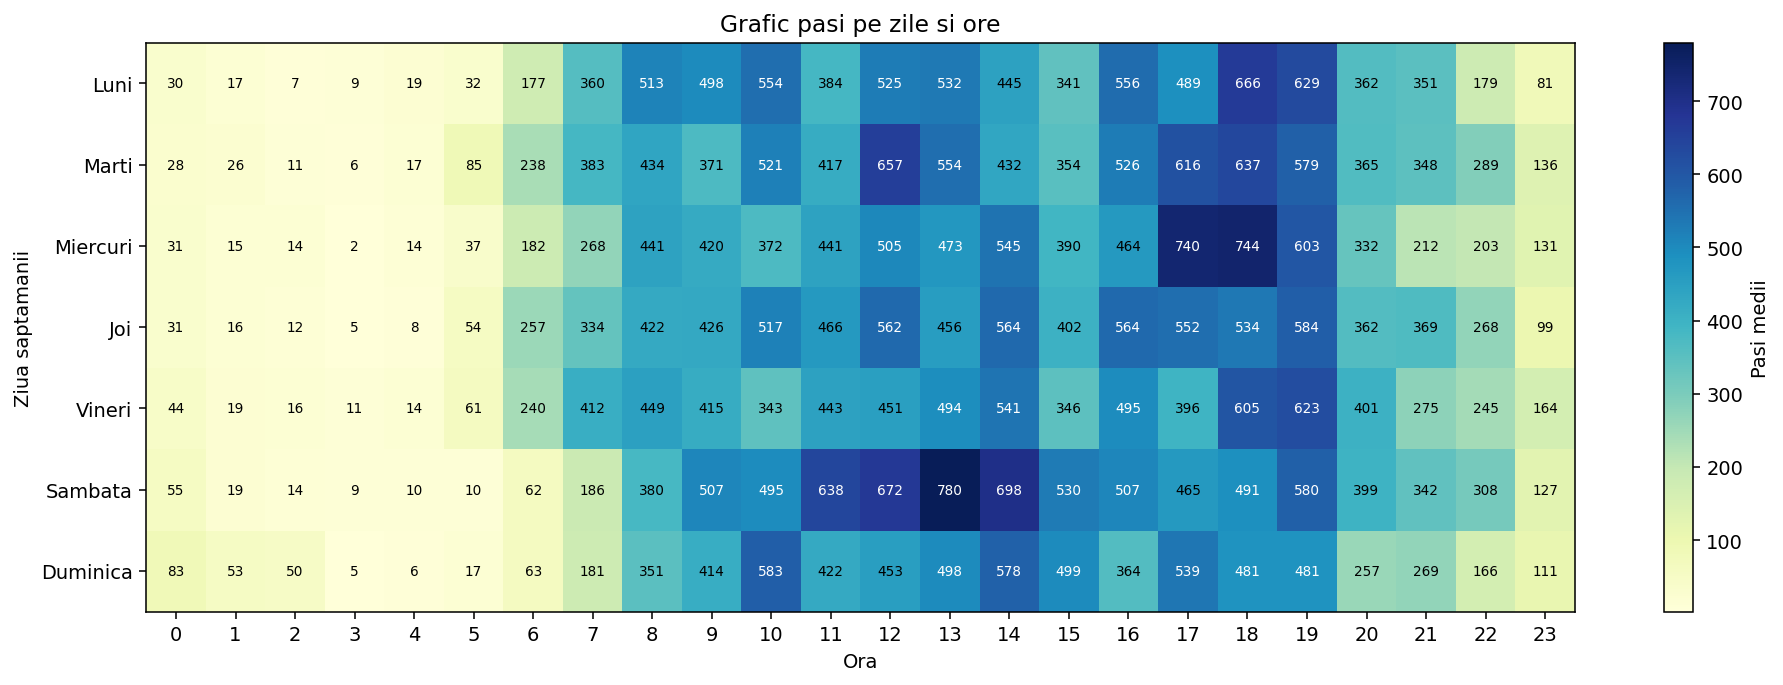

In [131]:
weekday_order = ["Luni", "Marti", "Miercuri", "Joi", "Vineri", "Sambata", "Duminica"]
weekday_map = {
    0: "Luni", 1: "Marti", 2: "Miercuri", 3: "Joi", 4: "Vineri", 5: "Sambata", 6: "Duminica"
}

hourly_steps_viz["WeekdayRo"] = hourly_steps_viz["DateTime"].dt.dayofweek.map(weekday_map)
heat_data = hourly_steps_viz.groupby(["WeekdayRo", "Hour"], as_index=False)["StepTotal"].mean()
heat_pivot = heat_data.pivot(index="WeekdayRo", columns="Hour", values="StepTotal")
heat_pivot = heat_pivot.reindex(weekday_order)

plt.figure(figsize=(14, 5), dpi=140)
im = plt.imshow(heat_pivot, aspect="auto", cmap="YlGnBu", interpolation="nearest")
plt.colorbar(im, label="Pasi medii")
plt.title("Grafic pasi pe zile si ore")
plt.xlabel("Ora")
plt.ylabel("Ziua saptamanii")
plt.xticks(ticks=range(24), labels=range(24))
plt.yticks(ticks=range(len(heat_pivot.index)), labels=heat_pivot.index)

threshold = heat_pivot.max().max() * 0.6
for y, day in enumerate(heat_pivot.index):
    for x in range(24):
        val = heat_pivot.iloc[y, x]
        if pd.notna(val):
            color = "white" if val > threshold else "black"
            plt.text(x, y, f"{val:.0f}", ha="center", va="center", fontsize=7, color=color)

plt.tight_layout()
plt.show()
